In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Part 1. Pandas analysis

In [2]:
df_ratings = pd.read_csv('ratings.csv').iloc[:,:-1]
df_ratings.sample(5)

,userId,movieId,rating
96467,603,1428,3.0
4071,27,364,4.0
68361,443,64957,4.0
79627,495,7360,4.5
95865,601,47,4.0


In [3]:
df_ratings

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0
...,...,...,...
100831,610,166534,4.0
100832,610,168248,5.0
100833,610,168250,5.0
100834,610,168252,5.0


Question 1. How many unique users are in the userId column?

In [4]:
df_unique = df_ratings.nunique()
df_unique['userId']

610

Question 2. How many unique movies are in the data?

In [5]:
df_unique['movieId']

9724

Question 3. Which movie has the most top rating?

In [6]:
df_ratings['rating'].max()

5.0

In [12]:
four_score = df_ratings['rating'] == 4
four_score

0          True
1          True
2          True
3         False
4         False
          ...  
100831     True
100832    False
100833    False
100834    False
100835    False
Name: rating, Length: 100836, dtype: bool

In [14]:
df_four = df_ratings[df_ratings['rating'] == 4]
df_four

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
7,1,110,4.0
14,1,235,4.0
...,...,...,...
100813,610,157296,4.0
100824,610,161582,4.0
100825,610,161634,4.0
100830,610,166528,4.0


In [7]:
highest_rated_movie = df_ratings[df_ratings['rating'] == df_ratings['rating'].max()]
highest_rated_movie

,userId,movieId,rating
3,1,47,5.0
4,1,50,5.0
6,1,101,5.0
8,1,151,5.0
9,1,157,5.0
...,...,...,...
100814,610,158238,5.0
100829,610,164179,5.0
100832,610,168248,5.0
100833,610,168250,5.0


In [8]:
one_movie = highest_rated_movie.sample(1)
one_movie

,userId,movieId,rating
58334,381,4878,5.0


Question 4. What is the title of the movie?

In [9]:
df_movie = pd.read_csv('movies.csv')
df_movie.sample(5)

,movieId,title,genres
7030,68791,Terminator Salvation (2009),Action|Adventure|Sci-Fi|Thriller
6044,39869,Manderlay (2005),Drama
3913,5500,Top Secret! (1984),Comedy
6779,60289,Kit Kittredge: An American Girl (2008),Children|Comedy|Drama|Mystery
281,322,Swimming with Sharks (1995),Comedy|Drama


In [10]:
movie_id = one_movie.iloc[0]['movieId']
movie_id

4878.0

In [11]:
df_movie.loc[df_movie['movieId'] == 4878]

,movieId,title,genres
3562,4878,Donnie Darko (2001),Drama|Mystery|Sci-Fi|Thriller


Question 5. What is the movie which as most users gave their ratings?

In [12]:
most_rated_movie = df_ratings[df_ratings['userId'] == df_ratings['userId'].max()]
most_rated_movie

,userId,movieId,rating
99534,610,1,5.0
99535,610,6,5.0
99536,610,16,4.5
99537,610,32,4.5
99538,610,47,5.0
...,...,...,...
100831,610,166534,4.0
100832,610,168248,5.0
100833,610,168250,5.0
100834,610,168252,5.0


In [13]:
most_rated_movie.sample(1)

,userId,movieId,rating
100535,610,91233,4.0


In [14]:
df_movie.loc[df_movie['movieId'] == 91233]

,movieId,title,genres
7752,91233,Lifted (2006),Animation|Comedy|Sci-Fi


Part 2. Linear Regression

In [15]:
df_adv = pd.read_csv('Advertising.csv').iloc[:,1:]
df_adv.sample(5)

,TV,Radio,Newspaper,Sales
108,13.1,0.4,25.6,5.3
100,222.4,4.3,49.8,11.7
73,129.4,5.7,31.3,11.0
111,241.7,38.0,23.2,21.8
28,248.8,27.1,22.9,18.9


Question 6. Randomly select 60 data from the data frame above. Use the data to learn the parameters (slope and intercept) of the model Sales = m * Radio + b. Please report the two parameters.

In [25]:
df_sample = df_adv.sample(60)
df_sample

,TV,Radio,Newspaper,Sales
77,120.5,28.5,14.2,14.2
34,95.7,1.4,7.4,9.5
126,7.8,38.9,50.6,6.6
123,123.1,34.6,12.4,15.2
80,76.4,26.7,22.3,11.8
178,276.7,2.3,23.7,11.8
63,102.7,29.6,8.4,14.0
199,232.1,8.6,8.7,13.4
0,230.1,37.8,69.2,22.1
169,284.3,10.6,6.4,15.0


In [26]:
x = df_sample.iloc[:]['TV'].values.reshape(-1,1)
y = df_sample.iloc[:]['Sales'].values.reshape(-1,1)

In [27]:
model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [28]:
m = model.coef_.item()
b = model.intercept_.item()

In [29]:
m

0.043044390615815296

In [30]:
b

7.847166169841095

Question 7. Visualize the data, the model, and the deivation between the true sales values and the predictive values.

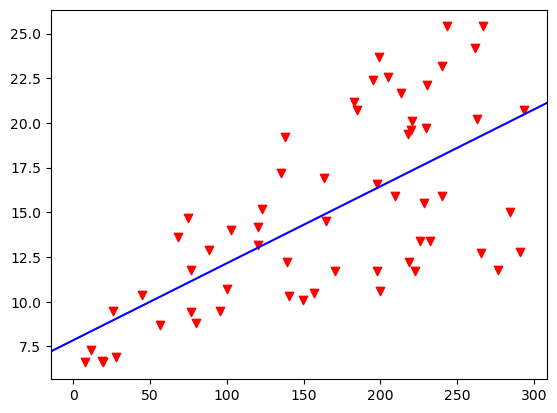

In [32]:
plt.scatter(x,y, marker='v', color = 'red')
plt.axline((0,b), slope = m, color = 'blue')

In [33]:
pred = m*x+b
pred

array([[13.03401524],
       [11.96651435],
       [ 8.18291242],
       [13.14593065],
       [11.13575761],
       [19.75754905],
       [12.26782509],
       [17.83776923],
       [17.75168045],
       [20.08468642],
       [13.78298764],
       [11.2993263 ],
       [19.26253856],
       [ 8.68222735],
       [15.80607399],
       [ 9.76264155],
       [17.03714357],
       [13.02110192],
       [ 8.94910257],
       [ 8.35078554],
       [16.35273776],
       [13.88629417],
       [15.7070719 ],
       [17.67420055],
       [17.25236552],
       [18.31556197],
       [10.79140249],
       [19.15492758],
       [11.13575761],
       [11.64798586],
       [17.42023864],
       [18.17351548],
       [17.56658957],
       [14.92796843],
       [13.83894534],
       [ 8.65209627],
       [15.17332145],
       [16.2580401 ],
       [16.67126625],
       [17.3384543 ],
       [20.48499925],
       [14.29521588],
       [17.30832323],
       [17.21793001],
       [12.16882299],
       [16

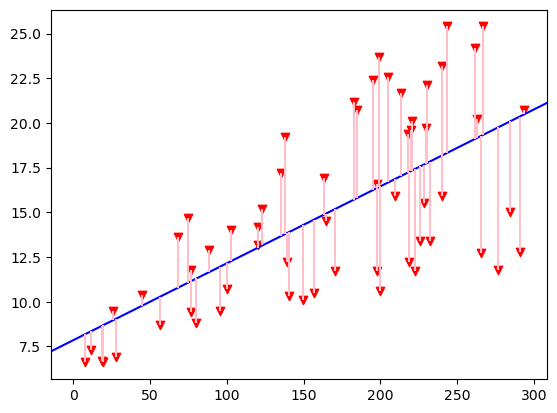

In [35]:
plt.scatter(x,y, marker='v', color = 'red')
plt.axline((0,b), slope = m, color = 'blue')
plt.vlines(x, ymin=pred, ymax=y, color = 'pink')

Question 8. We want to know the variation of the parameters when the selected data are different. Now let's use a for loop to repeat Q6, and store all the slopes in one list. Can you visualize the distribution of the slopes?

In [36]:
#Sorry Professor, I used my notes to figure out how to solve the rest but I don't know how to solve this one

Question 9. We also want to know the variation of the mean squared error made by the model. Can you also use a for loop to repeat the fitting one hunderd times and store all the MSE in a list. Visualize your distribution over the MSE.

In [37]:
mse_list = []
x_list = []

In [39]:
for iter in range(1,101):
    df_sample = df_adv.sample(iter)

    x = df_sample.iloc[:]['TV'].values.reshape(-1,1)
    y = df_sample.iloc[:]['Sales'].values.reshape(-1,1)

    model1 = LinearRegression()
    model1.fit(x,y)

    m = model1.coef_.item()
    b = model1.intercept_.item()
    predicted = x * m + b
    x_list.append(iter)
    mse_list.append(((predicted-y)**2).mean())

In [40]:
len(mse_list)

200

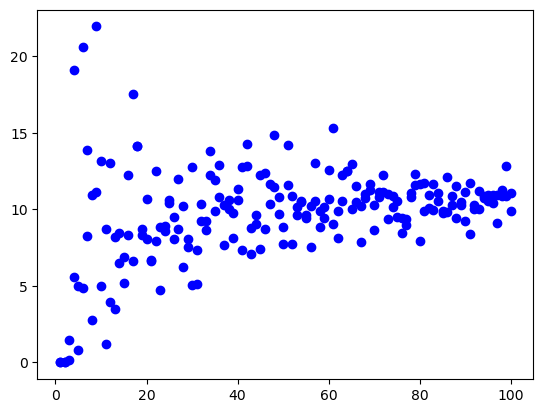

In [41]:
plt.scatter(x_list, mse_list, color = 'blue')

Question 10. Compare the two models 1). Sales = m * TV + b, 2). Sales = m * Newspapers + b. Use the metrics of mean-squared error for test data. Hint. your can try fitting the model 100 times with different selected training data.

In [45]:
mse_train = []
mse_test = []

mse_train2 = []
mse_test2 = []

for _ in range(100):
    df_train, df_test = train_test_split(df_adv, test_size = 0.2)
    
    x_train_model1 = df_train['TV'].values.reshape(-1,1)
    y_train_model1 = df_train['Sales'].values.reshape(-1,1)
    x_train_model2 = df_train['Newspaper'].values.reshape(-1,1)
    
    x_test_model1 = df_test['TV'].values.reshape(-1,1)
    y_test_model1 = df_test['Sales'].values.reshape(-1,1)
    x_test_model2 = df_test['Newspaper'].values.reshape(-1,1)
    
    model1= LinearRegression()
    model1.fit(x_train_model1, y_train_model1)
    
    model2 = LinearRegression()
    model2.fit(x_train_model2, y_train_model1)
    
    m_model1 = model1.coef_.item()
    b_model1 = model1.intercept_.item()
    
    m_model2 = model2.coef_.item()
    b_model2 = model2.intercept_.item()
    
    pred_train_model1 = m_model1 = x_train_model1 = b_model1
    pred_test_model1 = m_model1 = x_test_model1 = b_model1
    
    pred_train_model2 = m_model2 = x_train_model2 = b_model2
    pred_test_model2 = m_model2 = x_test_model2 = b_model2
    
    
    mse_train_model1= ((y_train_model1 - pred_train_model1) **2).mean()
    mse_test_model1= ((y_test_model1 - pred_test_model1) **2).mean()
    
    mse_train_model2= ((y_train_model1 - pred_train_model2) **2).mean()
    mse_test_model2= ((y_test_model1 - pred_test_model2) **2).mean()
    
    
    mse_train.append(mse_train_model1)
    mse_test.append(mse_test_model1)
    
    mse_train2.append(mse_train_model2)
    mse_test2.append(mse_test_model2)

(array([ 5.,  6.,  9., 20., 25., 15.,  9.,  7.,  2.,  2.]),
 array([16.0516912 , 19.31357493, 22.57545867, 25.8373424 , 29.09922614,
        32.36110987, 35.62299361, 38.88487734, 42.14676107, 45.40864481,
        48.67052854]),
 <BarContainer object of 10 artists>)

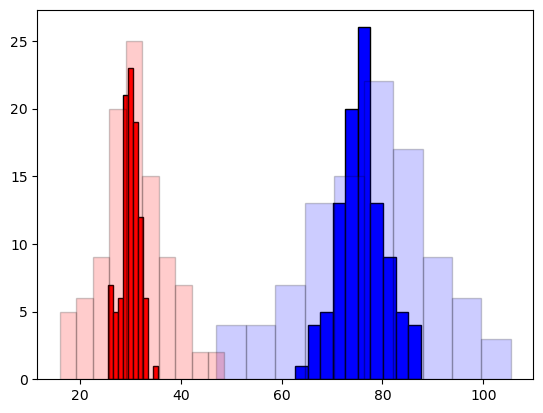

In [50]:
plt.hist(mse_train, edgecolor = 'k', color = 'blue')
plt.hist(mse_test, edgecolor = 'k', color = 'blue', alpha = 0.2)
plt.hist(mse_train2, edgecolor = 'k', color = 'red') 
plt.hist(mse_test2, edgecolor = 'k', color = 'red', alpha = 0.2)